# Heart Disease Predictor

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load the dataset
file_path = 'D:/Dataset/dataset_heart.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


### Exploratory Data Analysis (EDA)

In [4]:
print("DataFrame Shape:")
display(df.shape)

print("\nDataFrame Info:")
display(df.info())

print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Shape:


(270, 14)


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major vessels

None


Descriptive Statistics:


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


### Check for Missing Values

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
total_missing = df.isnull().sum().sum()

print("Missing values per column:")
display(missing_values)

print(f"\nTotal missing values in the dataset: {total_missing}")

if total_missing == 0:
    print("\nGreat news! There are no missing values in the dataset.")
else:
    print("\nAction needed: Please address the missing values as appropriate for your analysis.")

Missing values per column:


age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral                       0
fasting blood sugar                     0
resting electrocardiographic results    0
max heart rate                          0
exercise induced angina                 0
oldpeak                                 0
ST segment                              0
major vessels                           0
thal                                    0
heart disease                           0
dtype: int64


Total missing values in the dataset: 0

Great news! There are no missing values in the dataset.


## Check Column Names

In [7]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal', 'heart disease']


## Handle Duplicates

In [8]:
print(f"Initial DataFrame shape: {df.shape}")
duplicates_before = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_before}")

if duplicates_before > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New DataFrame shape: {df.shape}")
else:
    print("No duplicate rows found.")

Initial DataFrame shape: (270, 14)
Number of duplicate rows found: 0
No duplicate rows found.


## Separate Features and Target

In [9]:
X = df.drop('heart disease', axis=1)
y = df['heart disease']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (270, 13)
Shape of target (y): (270,)


## Encode Categorical Features

In [10]:
X.rename(columns={'sex ': 'sex'}, inplace=True)

categorical_cols = ['sex', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'major vessels', 'thal']

# Apply one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("DataFrame X after one-hot encoding:")
display(X_encoded.head())
print("Shape of X after encoding:", X_encoded.shape)

DataFrame X after one-hot encoding:


,age,resting blood pressure,serum cholestoral,max heart rate,oldpeak,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting electrocardiographic results_1,resting electrocardiographic results_2,exercise induced angina_1,ST segment_2,ST segment_3,major vessels_1,major vessels_2,major vessels_3,thal_6,thal_7
0,70,130,322,109,2.4,True,False,False,True,False,False,True,False,True,False,False,False,True,False,False
1,67,115,564,160,1.6,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True
2,57,124,261,141,0.3,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,64,128,263,105,0.2,True,False,False,True,False,False,False,True,True,False,True,False,False,False,True
4,74,120,269,121,0.2,False,True,False,False,False,False,True,True,False,False,True,False,False,False,False


Shape of X after encoding: (270, 20)


## Spliting Dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (216, 20)
Shape of X_test: (54, 20)
Shape of y_train: (216,)
Shape of y_test: (54,)


## Scale Numerical Features

In [12]:
numerical_cols = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']

scaler = StandardScaler()

X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled_numerical = scaler.transform(X_test[numerical_cols])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = X_train_scaled_numerical
X_test_scaled[numerical_cols] = X_test_scaled_numerical

print("X_train_scaled head:")
display(X_train_scaled.head())
print("\nX_test_scaled head:")
display(X_test_scaled.head())

print("Numerical features scaled and combined with categorical features successfully.")

X_train_scaled head:


,age,resting blood pressure,serum cholestoral,max heart rate,oldpeak,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting electrocardiographic results_1,resting electrocardiographic results_2,exercise induced angina_1,ST segment_2,ST segment_3,major vessels_1,major vessels_2,major vessels_3,thal_6,thal_7
115,-0.632970,0.125095,0.406391,0.566128,-0.934304,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
33,0.465195,2.143222,1.478549,-0.397771,1.959634,True,False,False,True,False,False,True,True,False,True,False,False,False,False,True
184,-0.193704,-0.099142,-0.080953,1.048078,-0.934304,True,False,True,False,True,False,True,False,False,False,False,False,True,False,False
142,-0.523153,0.461449,-0.334372,0.609942,-0.423609,True,False,True,False,False,False,False,False,True,False,True,False,False,False,True
197,-0.083888,-1.220323,-0.704754,0.390874,0.427549,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False



X_test_scaled head:


,age,resting blood pressure,serum cholestoral,max heart rate,oldpeak,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting electrocardiographic results_1,resting electrocardiographic results_2,exercise induced angina_1,ST segment_2,ST segment_3,major vessels_1,major vessels_2,major vessels_3,thal_6,thal_7
30,0.245562,-0.211260,-0.412348,0.040365,-0.593840,True,False,True,False,False,False,True,False,True,False,True,False,False,False,True
116,-0.962419,-0.659732,-0.022472,-0.222516,-0.253377,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True
79,0.135745,-0.659732,-0.275891,1.267146,-0.253377,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
127,-0.303521,0.237213,-1.055642,0.872823,-0.849188,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False
196,0.355378,-1.780914,-0.041966,-1.186415,-0.083146,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False


Numerical features scaled and combined with categorical features successfully.


## Analyze Target Class Distribution

Distribution of 'heart disease' target variable:
heart disease
1    150
2    120
Name: count, dtype: int64

Percentage distribution of 'heart disease' target variable:
heart disease
1    55.555556
2    44.444444
Name: proportion, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_7612\3168453232.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


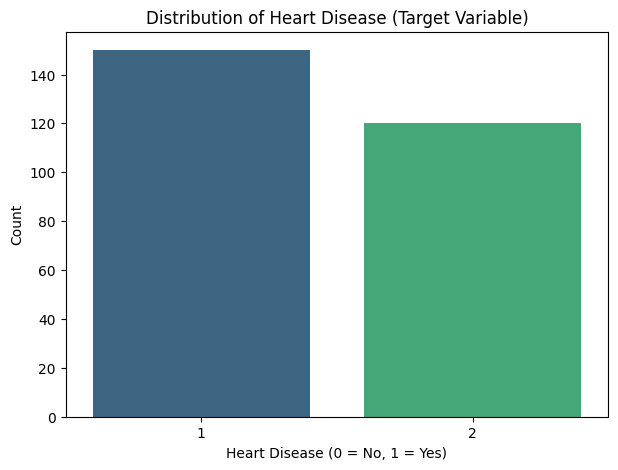

In [13]:
print("Distribution of 'heart disease' target variable:")
print(y.value_counts())
print("\nPercentage distribution of 'heart disease' target variable:")
print(y.value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


Distribution of 'heart disease' target variable:
heart disease
1    150
2    120
Name: count, dtype: int64

Percentage distribution of 'heart disease' target variable:
heart disease
1    55.555556
2    44.444444
Name: proportion, dtype: float64


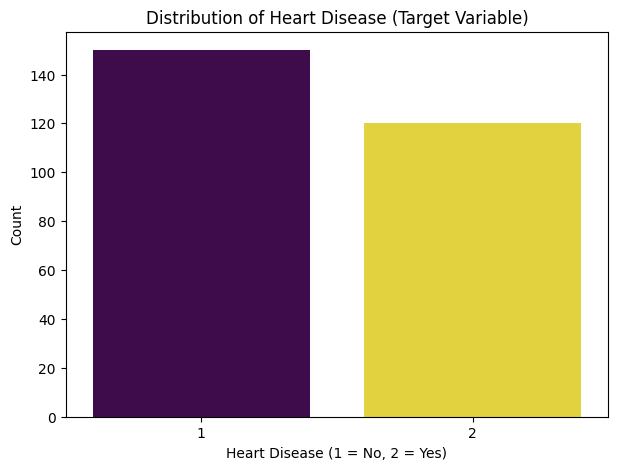

In [14]:
print("Distribution of 'heart disease' target variable:")
print(y.value_counts())
print("\nPercentage distribution of 'heart disease' target variable:")
print(y.value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
sns.countplot(x=y, hue=y, palette='viridis', legend=False)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (1 = No, 2 = Yes)')
plt.ylabel('Count')
plt.show()

## Visualize Feature Correlation

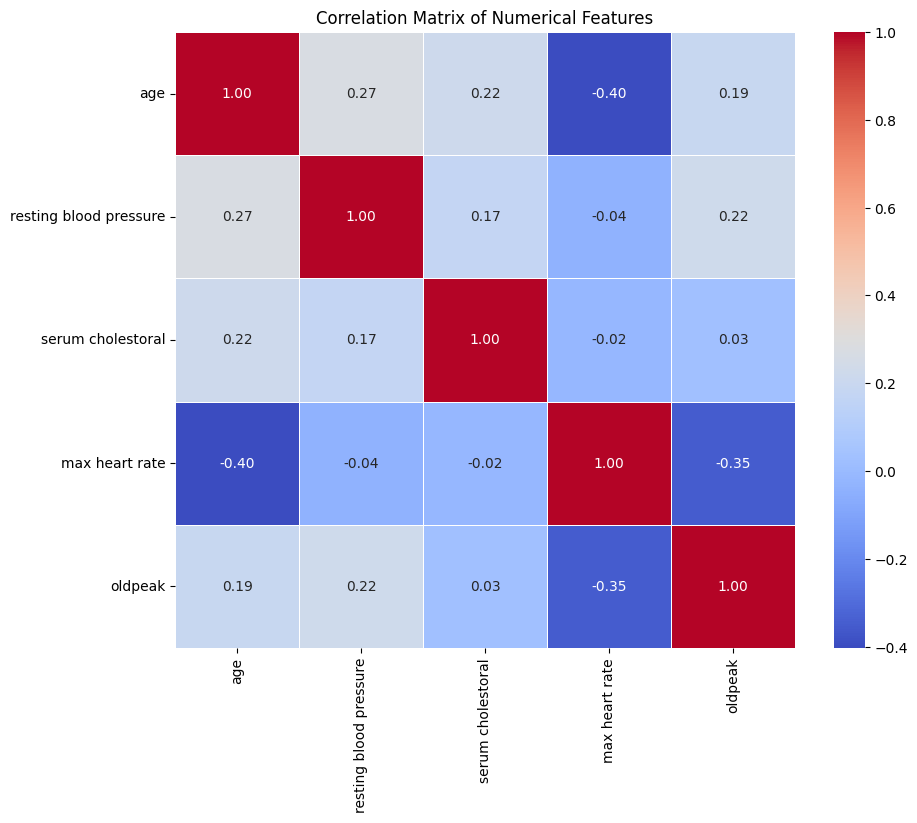

In [15]:
numerical_features_df = X_encoded[numerical_cols]
correlation_matrix = numerical_features_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## Visualize Categorical Feature Impact

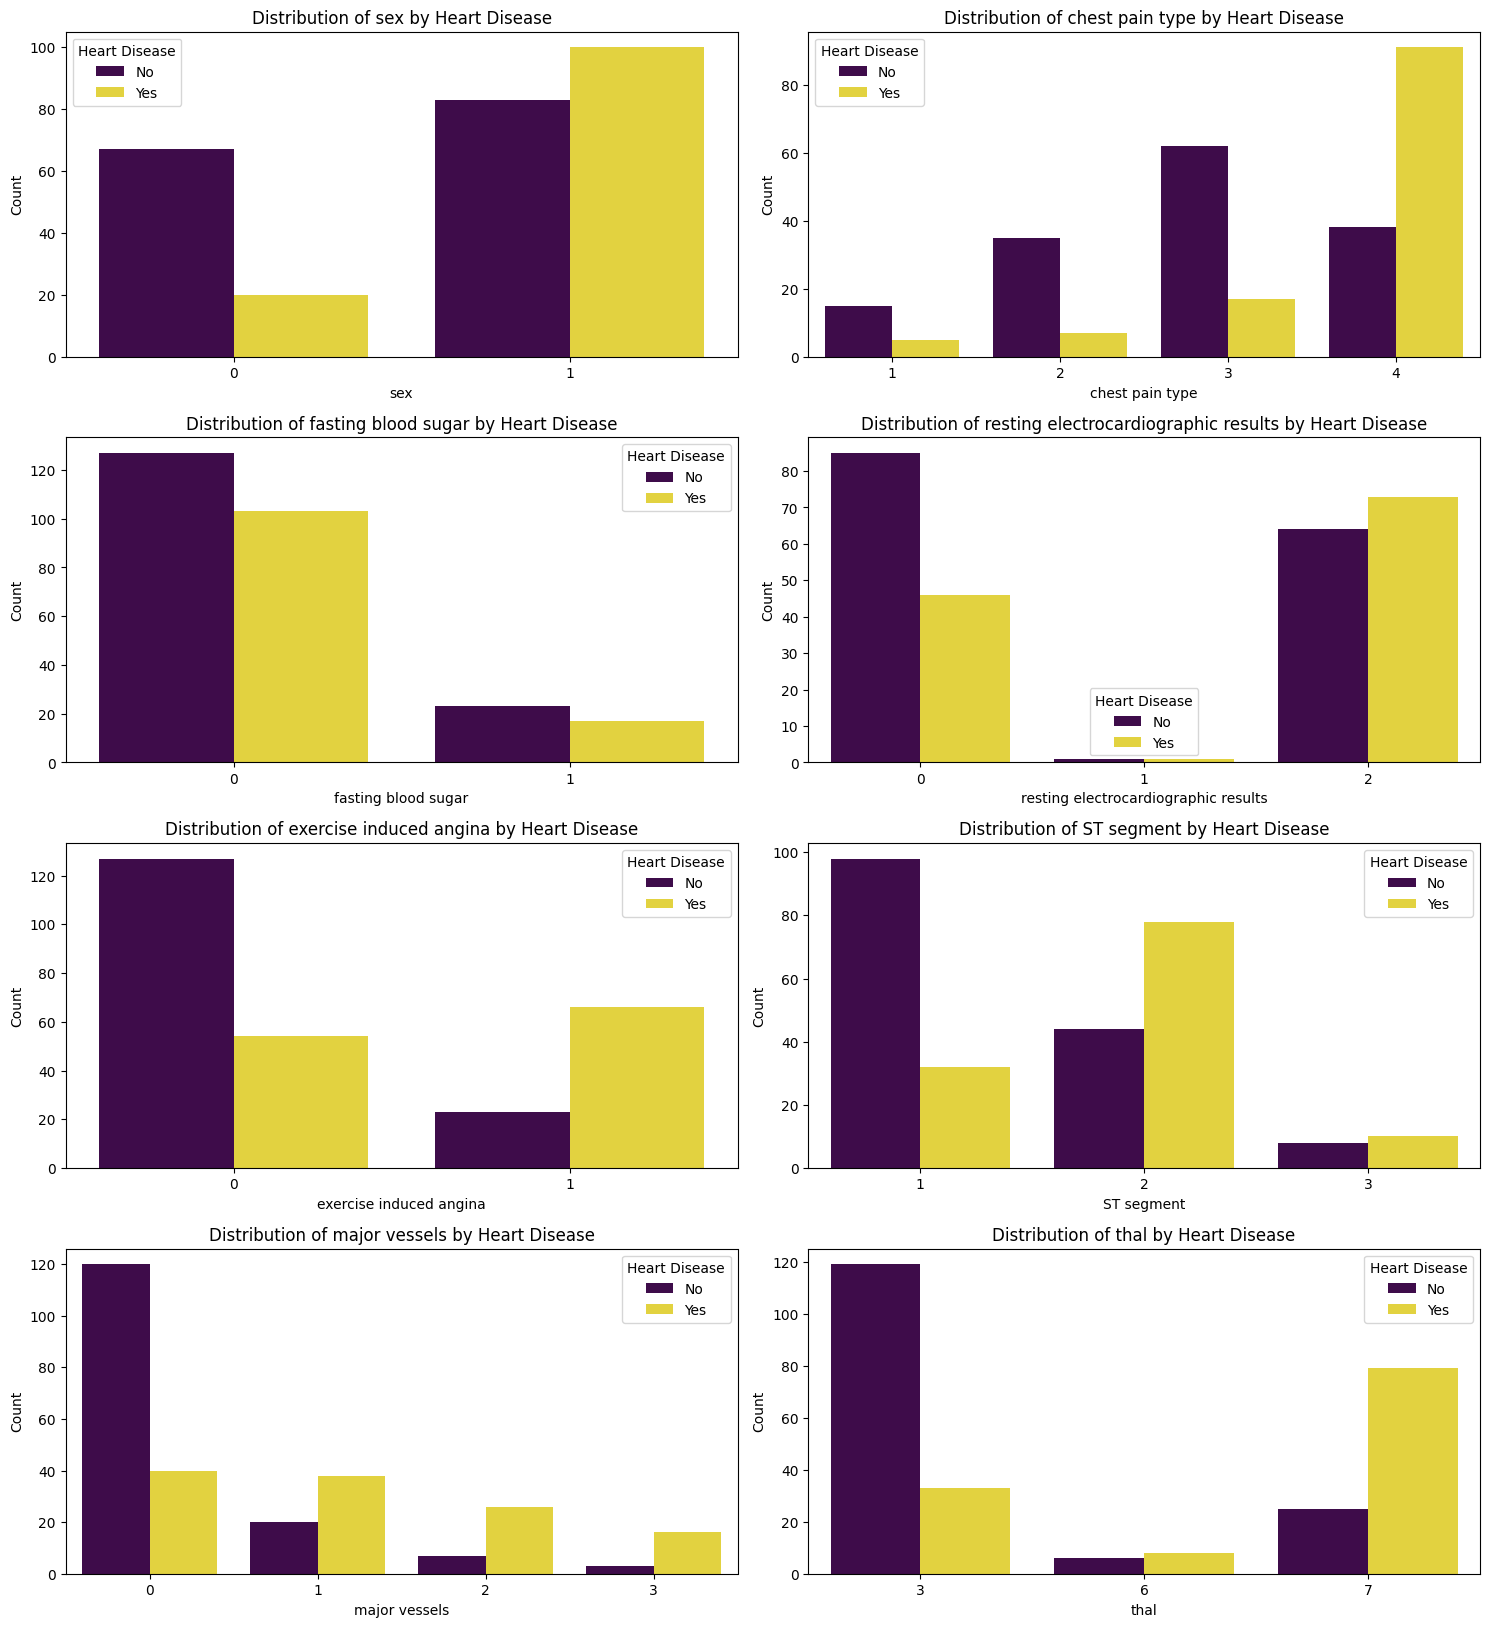

In [16]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols) // 2 + 1, 2, i + 1) # Adjust subplot layout dynamically
    sns.countplot(data=X, x=col, hue=y, palette='viridis')
    plt.title(f'Distribution of {col} by Heart Disease')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Heart Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

## Train Logistic Regression Model

Logistic Regression Model Performance:
Accuracy: 0.8519
Precision: 0.8551
Recall: 0.8519
F1-Score: 0.8483


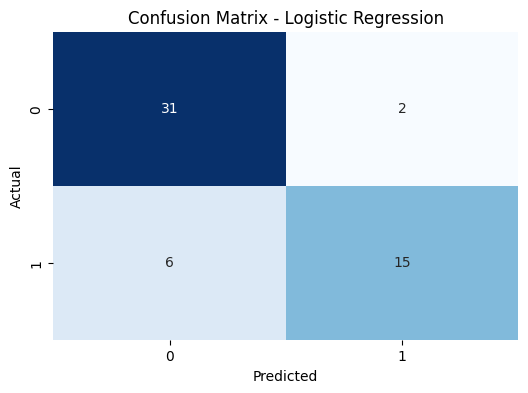

In [17]:
model_lr = LogisticRegression(solver='liblinear', random_state=42)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Train Support Vector Machine Model

Support Vector Machine Model Performance:
Accuracy: 0.7963
Precision: 0.7949
Recall: 0.7963
F1-Score: 0.7953


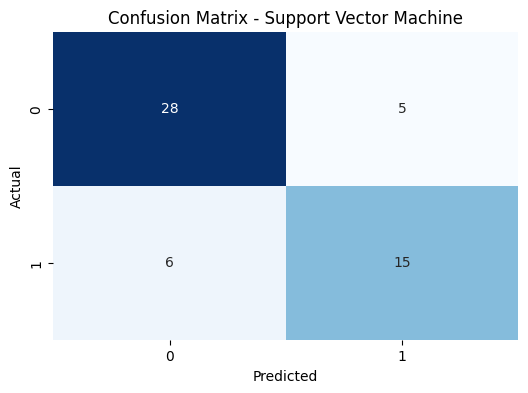

In [18]:
model_svc = SVC(kernel='rbf', random_state=42)
model_svc.fit(X_train_scaled, y_train)

y_pred_svc = model_svc.predict(X_test_scaled)

print("Support Vector Machine Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svc, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svc, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svc, average='weighted'):.4f}")

cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Train Random Forest Classifier Model

Random Forest Classifier Model Performance:
Accuracy: 0.7593
Precision: 0.7580
Recall: 0.7593
F1-Score: 0.7515


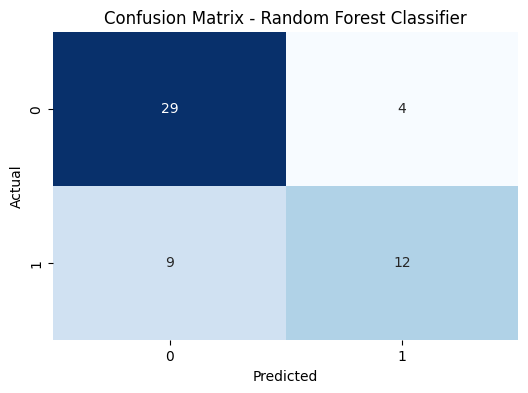

In [19]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

print("Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Train XGBoost Classifier Model

XGBoost Classifier Model Performance:
Accuracy: 0.7593
Precision: 0.7562
Recall: 0.7593
F1-Score: 0.7552


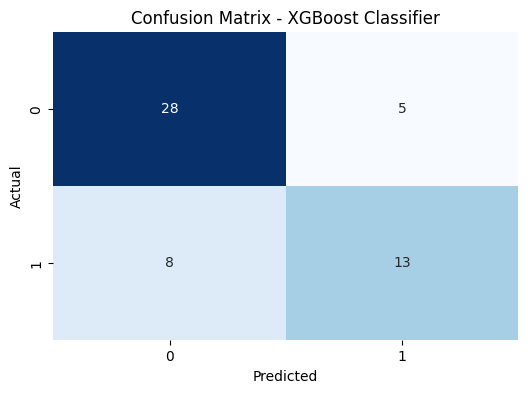

In [20]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

model_xgb = XGBClassifier(eval_metric='logloss', random_state=42)
model_xgb.fit(X_train_scaled, y_train_xgb)

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_score(y_test_xgb, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test_xgb, y_pred_xgb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test_xgb, y_pred_xgb, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test_xgb, y_pred_xgb, average='weighted'):.4f}")

cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Compare Model Performance

In [21]:
model_names = ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test_xgb, y_pred_xgb)
]
precisions = [
    precision_score(y_test, y_pred_lr, average='weighted'),
    precision_score(y_test, y_pred_svc, average='weighted'),
    precision_score(y_test, y_pred_rf, average='weighted'),
    precision_score(y_test_xgb, y_pred_xgb, average='weighted')
]
recalls = [
    recall_score(y_test, y_pred_lr, average='weighted'),
    recall_score(y_test, y_pred_svc, average='weighted'),
    recall_score(y_test, y_pred_rf, average='weighted'),
    recall_score(y_test_xgb, y_pred_xgb, average='weighted')
]
f1_scores = [
    f1_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_svc, average='weighted'),
    f1_score(y_test, y_pred_rf, average='weighted'),
    f1_score(y_test_xgb, y_pred_xgb, average='weighted')
]

performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})

performance_df = performance_df.round(4)

print("Model Performance Comparison:")
display(performance_df)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8519,0.8551,0.8519,0.8483
1,SVM,0.7963,0.7949,0.7963,0.7953
2,Random Forest,0.7593,0.7580,0.7593,0.7515
3,XGBoost,0.7593,0.7562,0.7593,0.7552


## Save Best Model

In [22]:
import joblib

best_model_row = performance_df.loc[performance_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']

if best_model_name == 'Logistic Regression':
    best_model = model_lr
elif best_model_name == 'SVM':
    best_model = model_svc
elif best_model_name == 'Random Forest':
    best_model = model_rf
elif best_model_name == 'XGBoost':
    best_model = model_xgb

# Save the best model
model_filename = f'best_heart_disease_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)

print(f"The best model is '{best_model_name}' with an accuracy of {best_model_row['Accuracy']:.4f}.")
print(f"Model saved to '{model_filename}'")

The best model is 'Logistic Regression' with an accuracy of 0.8519.
Model saved to 'best_heart_disease_model_logistic_regression.pkl'


## Make a Prediction with the Best Model

In [23]:
import joblib

# Load the best model
best_model_filename = 'best_heart_disease_model_logistic_regression.pkl'
loaded_model = joblib.load(best_model_filename)

print(f"Loaded the best model: {best_model_filename}")

Loaded the best model: best_heart_disease_model_logistic_regression.pkl


Now, let's create some sample data for prediction. This data needs to be preprocessed in the same way our training data was.

In [24]:
# Create sample data for prediction (example values)
sample_data = pd.DataFrame({
    'age': [55],
    'sex ': [1], # Male
    'chest pain type': [2], # Atypical angina
    'resting blood pressure': [140],
    'serum cholestoral': [240],
    'fasting blood sugar': [0], # < 120 mg/dl
    'resting electrocardiographic results': [0], # Normal
    'max heart rate': [160],
    'exercise induced angina': [0], # No
    'oldpeak': [1.5],
    'ST segment': [1], # Upsloping
    'major vessels': [0],
    'thal': [3] # Normal
})

# Ensure column names match original X before encoding
sample_data.rename(columns={'sex ': 'sex'}, inplace=True)

print("Sample data for prediction:")
display(sample_data)

Sample data for prediction:


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal
0,55,1,2,140,240,0,0,160,0,1.5,1,0,3


### Preprocess Sample Data

In [25]:
# Apply one-hot encoding using the same categorical columns
sample_data_encoded = pd.get_dummies(sample_data, columns=categorical_cols, drop_first=True)

# Align columns - crucial for prediction if new sample doesn't have all categories
# Add missing columns with 0
missing_cols = set(X_train_scaled.columns) - set(sample_data_encoded.columns)
for c in missing_cols:
    sample_data_encoded[c] = 0
# Ensure the order of columns is the same as training data
sample_data_encoded = sample_data_encoded[X_train_scaled.columns]

# Scale numerical features using the *fitted* scaler
sample_data_scaled_numerical = scaler.transform(sample_data_encoded[numerical_cols])
sample_data_encoded[numerical_cols] = sample_data_scaled_numerical

print("Preprocessed sample data:")
display(sample_data_encoded)

Preprocessed sample data:


,age,resting blood pressure,serum cholestoral,max heart rate,oldpeak,sex_1,chest pain type_2,chest pain type_3,chest pain type_4,fasting blood sugar_1,resting electrocardiographic results_1,resting electrocardiographic results_2,exercise induced angina_1,ST segment_2,ST segment_3,major vessels_1,major vessels_2,major vessels_3,thal_6,thal_7
0,0.025929,0.461449,-0.197916,0.478501,0.342434,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
# Make prediction
prediction_proba = loaded_model.predict_proba(sample_data_encoded)

# The second column (index 1) typically corresponds to the positive class (Heart Disease)
heart_disease_probability = prediction_proba[0, 1] * 100

print(f"The model predicts a {heart_disease_probability:.2f}% risk of Heart Disease.")

The model predicts a 12.80% risk of Heart Disease.
